In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import sys, os
sys.path.insert(0, os.path.expanduser('~/my_ukb_thesis'))
from const_paths import SAVE_DIR

In [2]:
data_dir = SAVE_DIR
file_path = os.path.join(data_dir, 'model_development_70.parquet')
df_dev = pd.read_parquet(file_path)
print(f'Model-development set shape: {df_dev.shape}')

Model-development set shape: (321188, 28)


In [3]:
target_col = 'def_CVD_AF_HF_AFTER'
drop_cols = ['eid', target_col]

X_raw = df_dev.drop(columns=[col for col in drop_cols if col in df_dev.columns])
Y = df_dev[target_col]

feature_names = X_raw.columns.tolist()
print(f'number of candidate features: {len(feature_names)}')

number of candidate features: 26


In [4]:
# Single imputation using IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=42)
X_imputed_array = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed_array, columns=feature_names, index=X_raw.index)

In [5]:
# standardization
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_names, index=X_raw.index)

In [6]:
# elastic net
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

elastic_net_model = LogisticRegressionCV(
    Cs=np.logspace(-4, 1, 12),
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
    scoring='roc_auc',
    class_weight='balanced',
    cv=cv,
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
    refit=True
)

elastic_net_model.fit(X_scaled, Y)

y_pred_prob = elastic_net_model.predict_proba(X_scaled)[:, 1]
auc_score = roc_auc_score(Y, y_pred_prob)

print(f'Development apparent AUC: {auc_score:.4f}')
print(f'Best C: {elastic_net_model.C_[0]}')
print(f'Best l1_ratio: {elastic_net_model.l1_ratio_[0]}')

Development apparent AUC: 0.7287
Best C: 0.006579332246575682
Best l1_ratio: 0.5


In [7]:
coefficients = elastic_net_model.coef_[0]

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

feat_imp_df = feat_imp_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

retained_features = feat_imp_df[feat_imp_df['Abs_Coefficient'] > 1e-5]['Feature'].tolist()
zero_features = feat_imp_df[feat_imp_df['Abs_Coefficient'] <= 1e-5]['Feature'].tolist()

print(f"Number of features with non-zero coefficients: {len(retained_features)}")
print(f"Number of features shrunk to zero: {len(zero_features)}")

if len(zero_features) > 0:
    print(f'non significant features: {zero_features}')

print("\nFeatures with non-zero elastic-net coefficients:")
for idx, row in feat_imp_df.head(len(retained_features)).iterrows():
    print(f"{row['Feature']:>35} | coef: {row['Coefficient']:.4f}")

Number of features with non-zero coefficients: 26
Number of features shrunk to zero: 0

Features with non-zero elastic-net coefficients:
               age_defined_baseline | coef: 0.7052
                        genetic_sex | coef: 0.3860
                                BMI | coef: 0.2237
                           smk_curr | coef: 0.1840
                           FH_cvd_m | coef: 0.1132
                      mental_doctor | coef: 0.1034
                           FH_cvd_f | coef: 0.0893
                         uni_degree | coef: -0.0860
                         FH_cvd_sib | coef: 0.0816
                           alc_curr | coef: -0.0764
                           smk_prev | coef: 0.0583
                          PA_active | coef: -0.0391
                       MobUse_2-4yr | coef: 0.0341
                        MobUse_>8yr | coef: -0.0230
                          sleep_hrs | coef: -0.0219
                        MobUse_≤1yr | coef: 0.0214
                        mental_risk | coef

In [ ]:
coef_output_path = os.path.join(SAVE_DIR, "elastic_net_cv_coefficients.csv")
feat_imp_df.to_csv(coef_output_path, index=False)
print(f"Saved coefficient table: {coef_output_path}")

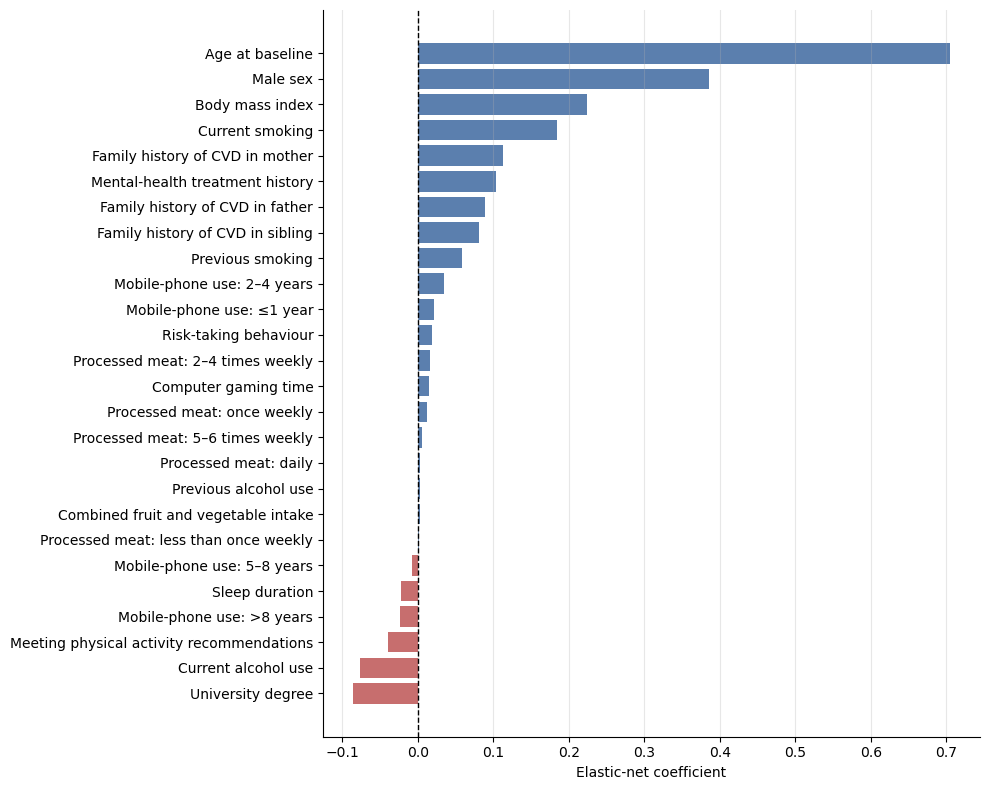

In [9]:
PLOT_LABELS = {
    "age_defined_baseline": "Age at baseline",
    "genetic_sex": "Male sex",
    "BMI": "Body mass index",
    "smk_curr": "Current smoking",
    "smk_prev": "Previous smoking",
    "alc_curr": "Current alcohol use",
    "alc_prev": "Previous alcohol use",
    "PA_active": "Meeting physical activity recommendations",
    "sleep_hrs": "Sleep duration",
    "uni_degree": "University degree",
    "FH_cvd_f": "Family history of CVD in father",
    "FH_cvd_m": "Family history of CVD in mother",
    "FH_cvd_sib": "Family history of CVD in sibling",
    "mental_doctor": "Mental-health treatment history",
    "mental_risk": "Risk-taking behaviour",
    "diet_total": "Combined fruit and vegetable intake",
    "device_pc": "Computer gaming time",
    "MobUse_≤1yr": "Mobile-phone use: ≤1 year",
    "MobUse_2-4yr": "Mobile-phone use: 2–4 years",
    "MobUse_5-8yr": "Mobile-phone use: 5–8 years",
    "MobUse_>8yr": "Mobile-phone use: >8 years",
    "ProcMeat_<1wk": "Processed meat: less than once weekly",
    "ProcMeat_1wk": "Processed meat: once weekly",
    "ProcMeat_2-4wk": "Processed meat: 2–4 times weekly",
    "ProcMeat_5-6wk": "Processed meat: 5–6 times weekly",
    "ProcMeat_daily": "Processed meat: daily"
}

plot_df = feat_imp_df.loc[feat_imp_df["Abs_Coefficient"] > 1e-5].copy()
plot_df["Label"] = plot_df["Feature"].map(PLOT_LABELS).fillna(plot_df["Feature"])
plot_df = plot_df.sort_values("Coefficient")

colors = ["#C76E6E" if x < 0 else "#5B7FAE" for x in plot_df["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["Label"], plot_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Elastic-net coefficient")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

figure_path = os.path.join(SAVE_DIR, "elastic_net_cv_coefficients_dev70.png")
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()


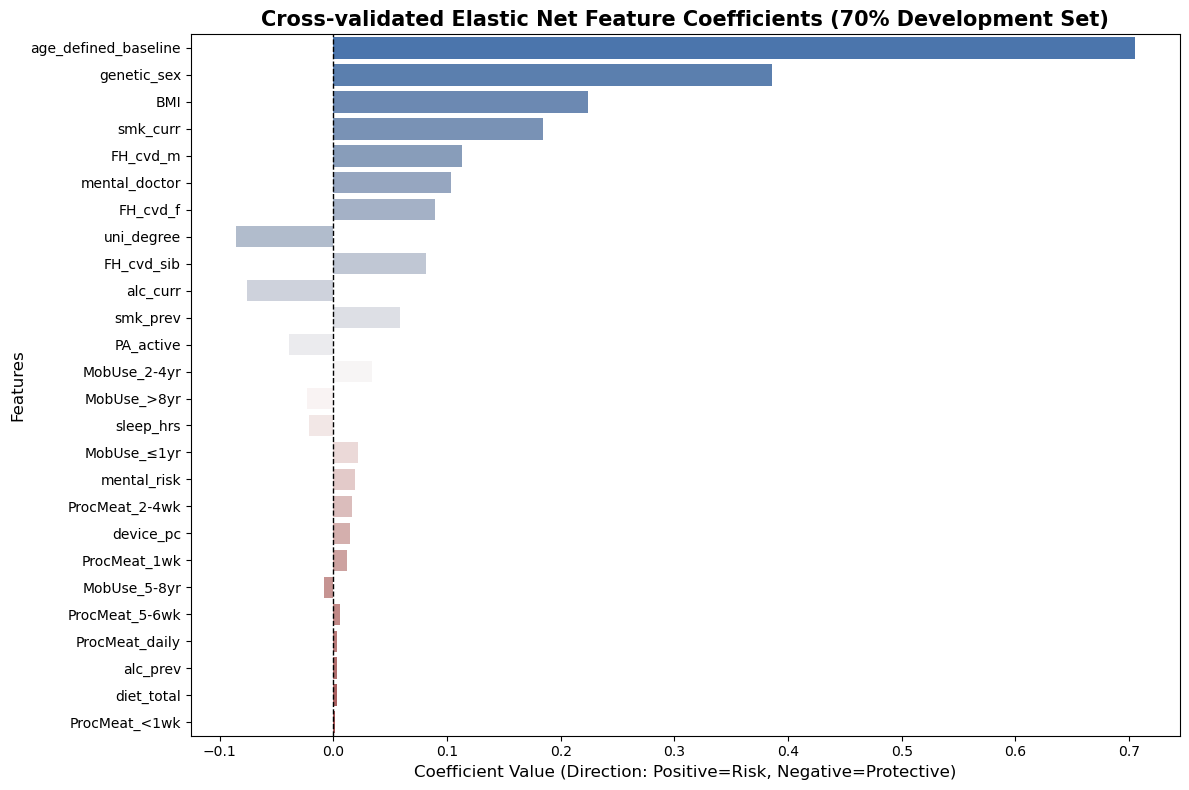

In [10]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x='Coefficient', 
    y='Feature', 
    hue='Feature',
    data=feat_imp_df[feat_imp_df['Abs_Coefficient'] > 1e-5], 
    palette='vlag',
    legend=False
)
plt.title('Cross-validated Elastic Net Feature Coefficients (70% Development Set)', fontsize=15, fontweight='bold')
plt.xlabel('Coefficient Value (Direction: Positive=Risk, Negative=Protective)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [11]:
print(f"Best C: {elastic_net_model.C_[0]}")
print(f"Best l1_ratio: {elastic_net_model.l1_ratio_[0]}")

coef_df = feat_imp_df.copy()
coef_df["selected_1e_5"] = coef_df["Abs_Coefficient"] > 1e-5
coef_df["selected_1e_3"] = coef_df["Abs_Coefficient"] > 1e-3
coef_df["selected_1e_2"] = coef_df["Abs_Coefficient"] > 1e-2

print("Non-zero using 1e-5:", coef_df["selected_1e_5"].sum())
print("Non-trivial using 1e-3:", coef_df["selected_1e_3"].sum())
print("Material using 1e-2:", coef_df["selected_1e_2"].sum())

display(coef_df)

Best C: 0.006579332246575682
Best l1_ratio: 0.5
Non-zero using 1e-5: 26
Non-trivial using 1e-3: 26
Material using 1e-2: 20


,Feature,Coefficient,Abs_Coefficient,selected_1e_5,selected_1e_3,selected_1e_2
0,age_defined_baseline,0.705222,0.705222,True,True,True
1,genetic_sex,0.385972,0.385972,True,True,True
2,BMI,0.223733,0.223733,True,True,True
3,smk_curr,0.184003,0.184003,True,True,True
4,FH_cvd_m,0.113231,0.113231,True,True,True
5,mental_doctor,0.103350,0.103350,True,True,True
6,FH_cvd_f,0.089278,0.089278,True,True,True
7,uni_degree,-0.085989,0.085989,True,True,True
8,FH_cvd_sib,0.081636,0.081636,True,True,True
9,alc_curr,-0.076410,0.076410,True,True,True


In [12]:
print("\n======= Elastic Net non-zero predictors =======")
print(retained_features)

print("\n======= Final predictors retained after clinical review =======")
final_features = [
    'age_defined_baseline', 'genetic_sex', 'BMI', 'uni_degree',
    'FH_cvd_f', 'FH_cvd_m', 'FH_cvd_sib',
    'sleep_hrs', 'mental_doctor',
    'smk_prev', 'smk_curr', 'alc_curr', 'PA_active'
]
print(final_features)

pd.DataFrame({"Feature": final_features}).to_csv(
    os.path.join(SAVE_DIR, "phase1_final_predictors.csv"),
    index=False
)


======= Elastic Net non-zero predictors =======
['age_defined_baseline', 'genetic_sex', 'BMI', 'smk_curr', 'FH_cvd_m', 'mental_doctor', 'FH_cvd_f', 'uni_degree', 'FH_cvd_sib', 'alc_curr', 'smk_prev', 'PA_active', 'MobUse_2-4yr', 'MobUse_>8yr', 'sleep_hrs', 'MobUse_≤1yr', 'mental_risk', 'ProcMeat_2-4wk', 'device_pc', 'ProcMeat_1wk', 'MobUse_5-8yr', 'ProcMeat_5-6wk', 'ProcMeat_daily', 'alc_prev', 'diet_total', 'ProcMeat_<1wk']

======= Final predictors retained after clinical review =======
['age_defined_baseline', 'genetic_sex', 'BMI', 'uni_degree', 'FH_cvd_f', 'FH_cvd_m', 'FH_cvd_sib', 'sleep_hrs', 'mental_doctor', 'smk_prev', 'smk_curr', 'alc_curr', 'PA_active']
